# Spectral analysis of Photron SA-Z high speed images

This program loads Sanjiv's cavitation nozzle images from Photron SA-Z, and calculates average spectra and spectral heat maps.

    @author Daniel Duke <daniel.duke@monash.edu>
    @copyright (c) 2026 D.Duke
    @license GPL-3.0+
    @version 0.0.1
    @date 23/03/2026
    
    Multiphase Flow Laboratory
    Monash University, Australia


In [1]:
# core functions for image handling and plotting
from pySciCam.pySciCam import ImageSequence # https://github.com/djorlando24/pySciCam

import numpy as np
import os
from tqdm.notebook import tqdm
from scipy.signal import welch
from joblib import Parallel, delayed

import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib widget

## Stage 1. Load images, crop, and remove background.


In [2]:
# Images to load

src_images = '/Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw'
#src_images = '/Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_1__5E4_K_1__12/nz_0__5_3_co2_00_Re_1__5E4_K_1__12.mraw'


In [3]:
# Load background
B=ImageSequence(src_images,width=1024,height=1024, rawtype='photron_mraw_mono_16bit',\
               frames=(0,800))

Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw
PFV 16-bit MRAW
File contains 10001 frames (1024 x 1024)
Reading frames 0 to 800
Read 1600.0 MiB in 17.6 sec
	Data in memory:	 (800, 1024, 1024)
	Intensity range:	 0 to 31088 	 uint16
	Array size:	1600.0 MB


In [4]:
# Find number of frames to analyze
nframes = os.path.getsize(src_images)//(B.width*B.height*2)
print("MRAW file has %i frames" % nframes)

MRAW file has 10001 frames


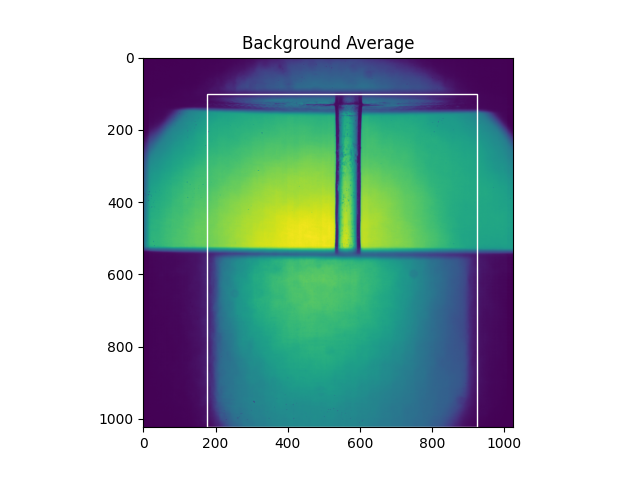

In [5]:
# Background averaging
avgBkgnd=np.nanmean(B.arr,axis=0)

# Show background and check cropping
fig=plt.figure()
crop=(100,1024,175,925)
plt.imshow(avgBkgnd)
cropBox=mpl.patches.Rectangle((crop[2],crop[0]),crop[3]-crop[2],crop[1]-crop[0],fc='None',ec='w')
fig.gca().add_patch(cropBox);
plt.title("Background Average");

#fig=plt.figure()
#plt.imshow(avgBkgnd[crop[0]:crop[1]+1,crop[2]:crop[3]+1])

# Apply to avgBkgnd
avgBkgnd=avgBkgnd[crop[0]:crop[1]+1,crop[2]:crop[3]+1]

# Remove original background images to save on memory
del B.arr

In [10]:
# Function to load some images and peform backgorund correction 
def load_chunk_of_images_from_mraw(filename,offset=0,width=1024,height=1024,\
                                   rawtype='photron_mraw_mono_16bit',\
                                   chunk_size=512):
    
    # Load chunk of frames to restrain RAM requirement
    Iset=ImageSequence(filename,width=width,height=height,rawtype=rawtype,\
               frames=(offset,offset+chunk_size))

    # Apply crop same as to bkgnd, from previous 
    Iset.arr = Iset.arr[:,crop[0]:crop[1]+1,crop[2]:crop[3]+1]
    
    # Assign memory to hold new images
    bkRmvSet = np.zeros((Iset.arr.shape[0],Iset.arr.shape[1],Iset.arr.shape[2]),dtype=np.float32)
    sumIntensSet = np.zeros((Iset.arr.shape[0],))
    sumIntensSet2= np.zeros((Iset.arr.shape[0],))
    
    # Background division of chunk
    for j in range(Iset.N):
        bkRmvSet[j,...] = avgBkgnd / (Iset.arr[j,...].astype(np.float32) +1)
        sumIntensSet[j]=np.nansum(bkRmvSet[j,...])//(Iset.arr.shape[1]*Iset.arr.shape[2])
        sumIntensSet2[j]=np.nansum(bkRmvSet[j,...]**2)//(Iset.arr.shape[1]*Iset.arr.shape[2])
        
    # clear ImageSequence instance
    del Iset
    
    return bkRmvSet, sumIntensSet, sumIntensSet2

In [11]:
# Run loading function in parallel
chunk_size=512
allOutput=Parallel(n_jobs=4, backend='threading', verbose=25)\
    (delayed(load_chunk_of_images_from_mraw)(src_images,i,chunk_size=chunk_size)\
     for i in range(B.N,nframes,chunk_size)) 

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mrawReading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw
Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw
PFV 16-bit MRAW

PFV 16-bit MRAW
PFV 16-bit MRAW
Reading /Volumes/DUKE SSD ext4/SanjivG_0.5mm_cavitation_imaging/nz_0__5_0_3/saz_20241217_far/nz_0__5_3_co2_00_Re_2__4E4_K_1__01/nz_0__5_3_co2_00_Re_2__4E4_K_1__01.mraw
File contains 10001 frames (1024 x 1024)
Reading frames 1312 to 1824
File contains 10001 frames (1024 x 1024)
Reading frames 800 to 1312
File contains 10001 frames (1024 x 1024)
Reading frames 1824 to 2336
PFV 16-bit MRAW
Read 1024.0 MiB in 11.2 secFile contains 10001 frames (102

[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:   47.8s


Read 1024.0 MiB in 12.4 sec
	Data in memory:	 (512, 1024, 1024)


[Parallel(n_jobs=4)]: Done   2 tasks      | elapsed:  1.0min
[Parallel(n_jobs=4)]: Done   3 tasks      | elapsed:  1.0min
[Parallel(n_jobs=4)]: Done   4 tasks      | elapsed:  1.0min


...

[Parallel(n_jobs=4)]: Done  14 out of  18 | elapsed:  3.5min remaining:  1.0min


	Intensity range:	 0 to 31120 	 uint16
	Array size:	1024.0 MB
Read 994.0 MiB in 12.5 sec
	Data in memory:	 (512, 1024, 1024)


[Parallel(n_jobs=4)]: Done  15 out of  18 | elapsed:  3.7min remaining:   44.7s


	Intensity range:	 0 to 31120 	 uint16
	Array size:	1024.0 MB


[Parallel(n_jobs=4)]: Done  16 out of  18 | elapsed:  3.7min remaining:   28.0s
[Parallel(n_jobs=4)]: Done  18 out of  18 | elapsed:  3.8min finished


In [12]:
# Transfer result into a single NumPy array

sumIntens  = np.hstack([ allOutput[n][1] for n in range(len(allOutput)) ], dtype=np.float32)
sumIntens2 = np.hstack([ allOutput[n][2] for n in range(len(allOutput)) ], dtype=np.float32)

bkRmv=np.zeros((len(sumIntens), avgBkgnd.shape[0], avgBkgnd.shape[1]),dtype=np.float32)
chunk_size=allOutput[0][0].shape[0]
for i in range(B.N,nframes,chunk_size):
    print(i)
    chunk_size=allOutput[0][0].shape[0]
    bkRmv[i-B.N:i-B.N+allOutput[0][0].shape[0],...]=allOutput[0][0][...]
    allOutput.pop(0)

  0%|          | 0/18 [00:00<?, ?it/s]

In [13]:
# Remove unneeded variables
del allOutput, B

In [35]:
# Save processed images
output_prefix = os.path.splitext(src_images)[0]
npy_path = output_prefix+'_bkRmv.npz'
np.savez(npy_path, sumIntens=sumIntens, sumIntens2=sumIntens2, bkRmv=bkRmv)
print("Wrote %.0f MB" % (os.path.getsize(npy_path)//1024//1024))

TypeError: unsupported operand type(s) for //: 'str' and 'int'

In [46]:
# Remove Outlier
sumIntens[sumIntens>np.nanmean(sumIntens)+3*np.nanstd(sumIntens)]=np.nan
sumIntens2[np.isnan(sumIntens)]=np.nan

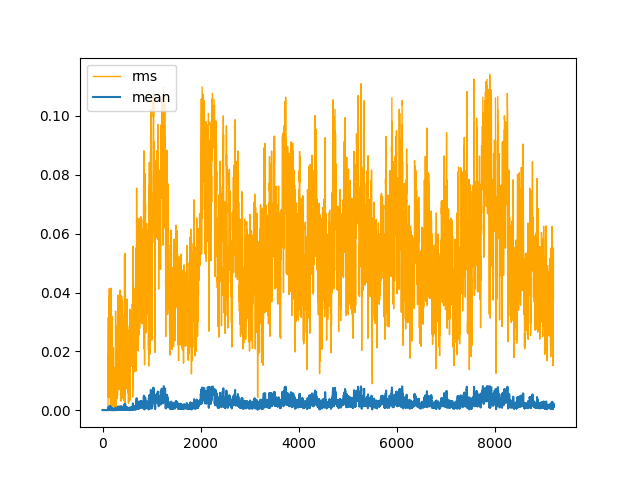

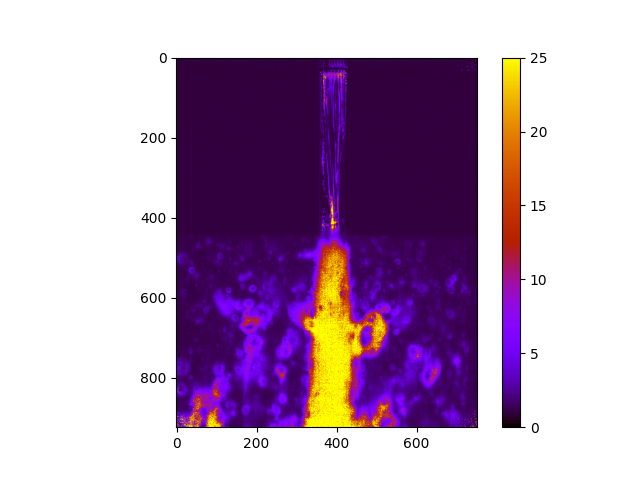

In [58]:
fig=plt.figure()
p1,=plt.plot(np.sqrt(sumIntens2-sumIntens**2)/float(len(sumIntens)+1),label='rms',c='orange',lw=1);
p2,=plt.plot(sumIntens/float(len(sumIntens)),label='mean');
plt.legend([p1,p2],['rms','mean']);

fig=plt.figure()
ph=plt.imshow(bkRmv[1000,...],cmap='gnuplot',vmin=0,vmax=25)#,vmin=0,vmax=0.01);
plt.colorbar(ph);

## Stage 2. Spectral analysis


In [9]:
# Load data back?

In [ ]:
nperseg=512 # output is half this

#welch_output = np.zeros((frames_array.shape[0],frames_array.shape[1], int(nperseg/2 + 1)))

# Computation of per-pixel spectra
def welch_fun(xx): #noverlap=int(nperseg * (3/4))
    return welch(xx, fs, nperseg=nperseg,\
                 detrend='linear', return_onesided=True,\
                 scaling='density')
    
def welch_vector(x):
    welch_output = np.zeros((x.shape[0], int(nperseg/2 + 1)))
    for j in range(x.shape[0]):
        f, Pxx = welch_fun(x[j,:])
        welch_output[j,:] = Pxx
    return welch_output

print("n=",frames_array.shape[0])

all_output = Parallel(n_jobs=-1, verbose=10)\
    (delayed(welch_vector)(frames_array[i,...]) for i in range(frames_array.shape[0]))